# CS541: Applied Machine Learning, Spring 2026, Lab 8
## Introduction to Convolutional Neural Networks & Transfer Learning

Convolutional Neural Networks (CNNs) are a specialized type of artificial neural network designed specifically to process data that has a known grid-like topology. The most common example is visual data (images and videos), where the spatial relationship between pixels contains critical information. CNNs leverage **Convolutional layers** to extract local features (like edges and textures), **Pooling layers** to reduce spatial dimensions and add translation invariance, and **Fully Connected layers** to make final classifications.

**The Dataset: CIFAR-10**
We will use the **CIFAR-10** dataset. It consists of 60,000 color images (32x32 pixels) divided into 10 classes (airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks), with 6,000 images per class. There are 50,000 training images and 10,000 test images.

The first half of the notebook is to introduce various CNN concepts. The second part involves questions for you to complete.

**Lab Objectives:**
1. Build and train a custom CNN from scratch on CIFAR-10.
2. Observe the impact of Optimizer Momentum on training speed and accuracy.
3. Visualize the learned filters of the first convolutional layer.
4. Learn how to leverage **Transfer Learning** by fine-tuning pre-trained models (ResNet18 and ResNet50) for a custom task.

**Lab Grading**
Labs are hands-on exercises designed to provide guided experience in key concepts through this class. You are graded based on in-lab participation (not correctness), and **are required to submit** your lab work after class, before Friday of that week. *Make sure you fill out the attendance form before leaving class*.

##  Computer vision libraries in PyTorch

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with `torch.utils.data.Dataset`). |    
    

## Typical CNN Framework

![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-4-59-29-pm.png)

### What does a CNN do?

![title](https://ujwlkarn.files.wordpress.com/2016/07/screen-shot-2016-07-24-at-11-25-13-pm.png?w=254&h=230)
![title](https://ujwlkarn.files.wordpress.com/2016/07/screen-shot-2016-07-24-at-11-25-24-pm.png?w=148&h=128)

![title](https://ujwlkarn.files.wordpress.com/2016/07/convolution_schematic.gif)

![title](https://ujwlkarn.files.wordpress.com/2016/08/giphy.gif)

![title](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*eoVNuUXZy5W2zb0CIK5IhQ.png)

In Practice a CNN will learn the values of these filters on its own, during the training process. Although, we would need to define the parameters of `nn.Conv2d()`:

* `in_channels` (int) - Number of channels in the input image.
* `out_channels` (int) - Number of channels produced by the convolution. (Number of filters)
* `kernel_size` (int or tuple) - Size of the convolving kernel/filter.
* `stride` (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.
* `padding` (int, tuple, str) - Padding added to all four sides of input. We can add extra pixels around the edges of the input image to make sure the filter properly passes over the edges of the image. A feature of zero padding is that it will allow us to control the spatial size of the output volumes. Used when its required to preserve the spatial size of the input volume so the input and output width and height are the same. Default: 0.

![example of going through the different parameters of a Conv2d layer](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv2d-layer.gif)

*Example of what happens when you change the hyperparameters of a `nn.Conv2d()` layer.*

In [ ]:
import torch.nn as nn
import torch
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
tensor = torch.randn(1, 3, 64, 64)
output = conv_layer(tensor)
print(conv_layer)
print(output.size())
print()

conv_layer_2 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1)
output_2 = conv_layer_2(tensor)
print(conv_layer_2)
print(output_2.size())

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([1, 16, 64, 64])

Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
torch.Size([1, 16, 32, 32])


We can compute the spatial size of the output volume as a function of the input volume size (W), the receptive field size of the Conv Layer neurons (F), the stride with which they are applied (S), and the amount of zero padding used (P) on the border. You can convince yourself that the correct formula for calculating how many neurons “fit” is given by     
    
O = (W−F+2P)/S+1.    
    
For example for a 7x7 input and a 3x3 filter with stride 1 and pad 0 we would get a 5x5 output. With stride 2 we would get a 3x3 output

### Pooling Layers

In [ ]:

max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
output_3 = max_pool_layer(tensor)
print(tensor.shape)
print(max_pool_layer)
print(output_3.size())

torch.Size([1, 3, 64, 64])
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
torch.Size([1, 3, 32, 32])


![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-10-at-3-38-39-am.png?w=988)

Pooling layer downsamples the volume spatially, independently in each depth slice of the input volume. Left: In this example, the input volume of size [224x224x64] is pooled with filter size 2, stride 2 into output volume of size [112x112x64]. Notice that the volume depth is preserved. Right: The most common downsampling operation is max, giving rise to max pooling, here shown with a stride of 2. That is, each max is taken over 4 numbers (little 2x2 square).

![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-6-11-53-pm.png)

The function of Pooling is to progressively reduce the spatial size of the input representation.
* It reduces the amount of parameters and computation in the network, and hence to also control overfitting.
* It makes the detection of features invariant to small transformations, distortions and translations. (a small distortion in input will not change the output of Pooling – since we take the maximum / average value in a local neighborhood).

Putting it all together:



![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-9-15-21-pm.png)

![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-10-at-12-58-30-pm.png?w=484)


Conv Layers - Transformations    
Pooling Layers - Downsampling

Key Principles of Convolutional Neural Networks:

- Sparse Interactions: In traditional neural networks, each output unit interacts with every input unit via matrix multiplication, resulting in dense connections. However, CNNs employ sparse interaction by using smaller kernels compared to the input data. For instance, while processing an image with millions of pixels, kernels can capture meaningful information within a smaller window of tens or hundreds of pixels. This sparse interaction reduces the number of parameters needed, leading to lower memory requirements and enhanced statistical efficiency of the model. It allows CNNs to focus on local patterns, efficiently capturing relevant features while ignoring irrelevant ones.

- Parameter Sharing: Traditional neural networks lack parameter sharing, leading to distinct weights applied only once and never revisited. However, in CNNs, the same set of weights is reused across the input, promoting efficient feature extraction and allowing the network to learn patterns that are applicable in various spatial locations.

- Equivariant Representations: Parameter sharing in CNN layers results in equivariance to translation. This property implies that if a transformation occurs in the input, the output undergoes a corresponding transformation. For instance, if an image is shifted or translated, the learned features or patterns in the output also shift accordingly. CNNs’ equivariant nature ensures that learned features retain their spatial relationships, making them robust and effective in recognizing patterns regardless of their position within the input data.

### Transposed Convolution

Where would you find them? - In the decoder part of an autoencoder, in the generator part of a GAN, in the upsampling part of a U-Net, etc.

Purpose? - To increase the size or spatial resolution of the input.

In [ ]:
conv_transpose = nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1)
input = torch.randn(1, 16, 4, 4)
output = conv_transpose(input)

print("Input shape:", input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 16, 4, 4])
Output shape: torch.Size([1, 3, 8, 8])


#### Is it the reverse of a Convolution?

- Not really, if you think about it, convolution can't be "reverted". You won't be able to recover the original values given the output of a convolutional layer. (Example below: Convolution results in a loss of information (around the edges of the image).)

- Although we cant revert the information lost, we can reverse the size reduction that happens in a convolutional layer. - Which is what transposed convolution does.


![title](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*SEvLW8SoeUqTkNZgZNFCNQ.png)

Example to show that convolution results in a loss of information (around the edges of the image).

![title](https://miro.medium.com/v2/resize:fit:1000/format:webp/1*SpxCUPzNfb9C8TiAcrRr5A.gif)

### Dilated Convolution

It is a technique that expands the kernel (input) by inserting holes between its consecutive elements. In simpler terms, it is the same as convolution but it involves pixel skipping, so as to cover a larger area of the input.

- Enables the network to have a larger receptive field without increasing the number of parameters.

In [ ]:
dilated_conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1, dilation=2)
# dilation = 2 means there is one pixel of space between the kernel elements

input = torch.randn(1, 1, 8, 8)

# Apply the dilated convolutional layer to the input
output = dilated_conv(input)

print("Input shape:", input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 1, 8, 8])
Output shape: torch.Size([1, 1, 6, 6])


![title](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/no_padding_no_strides.gif)    
Convolution   

![title](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/no_padding_no_strides_transposed.gif)    
Transposed Convolution    

![title](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/dilation.gif)    
Dilated Convolution

Blue maps are inputs, cyan maps are outputs

# Transfer Learning / Fine-Tuning with PyTorch


What is transfer learning?

**Transfer learning** allows us to take the patterns (also called weights) another model has learned from another problem and use them for our own problem.For example, we can take the patterns a computer vision model has learned from datasets such as [ImageNet](https://www.image-net.org/) (millions of images of different objects) and use them to a Custom Dataset. Or we could take the patterns from a [language model](https://developers.google.com/machine-learning/glossary#masked-language-model) (a model that's been through large amounts of text to learn a representation of language) and use them as the basis of a model to classify different text samples. The premise remains: find a well-performing existing model and apply it to your own problem.<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/06-transfer-learning-example-overview.png" alt="transfer learning overview on different problems" width=900/>*Example of transfer learning being applied to computer vision and natural language processing (NLP). In the case of computer vision, a computer vision model might learn patterns on millions of images in ImageNet and then use those patterns to infer on another problem. And for NLP, a language model may learn the structure of language by reading all of Wikipedia (and perhaps more) and then apply that knowledge to a different problem.*

## Why use transfer learning?

There are two main benefits to using transfer learning:

1. Can leverage an existing model (usually a neural network architecture) proven to work on problems similar to our own.
2. Can leverage a working model which has **already learned** patterns on similar data to our own. This often results in achieving **great results with less custom data**.




## Where to find pretrained models

| **Location** | **What's there?** | **Link(s)** |
| ----- | ----- | ----- |
| **PyTorch domain libraries** | Each of the PyTorch domain libraries (`torchvision`, `torchtext`) come with pretrained models of some form. The models there work right within PyTorch. | [`torchvision.models`](https://pytorch.org/vision/stable/models.html), [`torchtext.models`](https://pytorch.org/text/main/models.html), [`torchaudio.models`](https://pytorch.org/audio/stable/models.html), [`torchrec.models`](https://pytorch.org/torchrec/torchrec.models.html) |
| **HuggingFace Hub** | A series of pretrained models on many different domains (vision, text, audio and more) from organizations around the world. There's plenty of different datasets too. | https://huggingface.co/models, https://huggingface.co/datasets |
| **`timm` (PyTorch Image Models) library** | Almost all of the latest and greatest computer vision models in PyTorch code as well as plenty of other helpful computer vision features. | https://github.com/rwightman/pytorch-image-models|
| **Paperswithcode** | A collection of the latest state-of-the-art machine learning papers with code implementations attached. You can also find benchmarks here of model performance on different tasks. | https://paperswithcode.com/ |

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/06-transfer-learning-where-to-find-pretrained-models.png" alt="different locations to find pretrained neural network models" width=900/>



### Example

![title](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*8Z3To8OAwBBIj66p.jpg)

In [ ]:
import torch.nn as nn
import timm

num_classes = 4 # Replace num_classes with the number of classes in your data

# Load pre-trained model from timm
model = timm.create_model('resnet50', pretrained=True)
print(f'Original FC layer: {model.fc}')

# Modify the model head for fine-tuning
num_features = model.fc.in_features
print(f'Feature dimension: {num_features}')

# Additional linear layer and dropout layer
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)
print(f'Modified FC layer: {model.fc}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Original FC layer: Linear(in_features=2048, out_features=1000, bias=True)
Feature dimension: 2048
Modified FC layer: Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=4, bias=True)
)


### Freezing Full or Partial network

Freezing - fixing the weight of specific layer or entire network during fine tuning process. Network freezing allows us to retain the knowledge captured by the pre-trained model while only updating certain layers to adapt to the target task.

- if the pre-trained model has been trained on a large-scale dataset similar to the target task, freezing the entire network can help preserve the learned representations, preventing them from being overwritten. In this case, only the model’s head is modified and trained from scratch.

- freezing only a portion of the network. This approach is particularly useful when the pre-trained model has been trained on a dataset that is somewhat similar to the target task, but you believe that fine-tuning some of the more abstract or higher-level features could further improve performance. By doing so, you can adjust the deeper layers of the network to better suit the nuances of your specific task while still leveraging the lower-level feature representations learned from the large-scale dataset.

In [ ]:
model = timm.create_model('resnet50', pretrained=True)

# Freeze all the layers of the pre-trained model
for param in model.parameters():
    param.requires_grad = False

# Modify the model's head for a new task
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
# Freeze only the convolutional layers of the pre-trained model
for param in model.parameters():
    if isinstance(param, nn.Conv2d):
        param.requires_grad = False

# Modify the model's head for a new task
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
# Freeze specific layers (e.g.,the first two convolutional layers) of the pre-trained model
for name, param in model.named_parameters():
    if 'conv1' in name or 'layer1' in name:
        param.requires_grad = False

# Modify the model's head for a new task
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

Another way of fine-tuning is setting different learning rates for different parts of the network. For example, the learning rate for the pre-trained layers can be set to a smaller value than the learning rate for the new layers. This is because the pre-trained layers may already contain useful representations, and we don’t want to change them too much. On the other hand, the new layers are randomly initialized and need to be trained more aggressively.

In [ ]:
import torch
optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-4},
    {'params': model.layer1.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

In [ ]:
from torchsummary import summary
import torch
import torch.nn as nn
# Creating a CNN class
class ConvNeuralNet(nn.Module):
	#  Determine what layers and their order in CNN object
    def __init__(self, num_classes):
        super(ConvNeuralNet, self).__init__()

        self.conv_layers = nn.ModuleDict({
            'conv1': nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3),
            'conv2': nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
            'max_pool1': nn.MaxPool2d(kernel_size = 2, stride = 2),
            'conv3': nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            'conv4': nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3),
            'max_pool2': nn.MaxPool2d(kernel_size = 2, stride = 2)
        })

        self.fc_layers = nn.ModuleDict({
            'fc1': nn.Linear(1600, 128),
            'fc2': nn.Linear(128, num_classes)
        })

    # Progresses data across layers
    def forward(self, x):

        print(f"Input shape: {x.shape}")
        print()
        for layer_name, layer in self.conv_layers.items():
            x = layer(x)
            print(f"Shape after {layer_name}: {x.shape}")

        print()
        x = x.reshape(x.size(0), -1)
        print(f"Flattened shape after Conv Layers: {x.shape}")
        print()

        for layer_name, layer in self.fc_layers.items():
            x = layer(x)
            print(f"Shape after {layer_name}: {x.shape}")
        return x

cnn_model = ConvNeuralNet(num_classes=10)


In [ ]:
random_data = torch.randn(16, 3, 32, 32)
output = cnn_model(random_data)

Input shape: torch.Size([16, 3, 32, 32])

Shape after conv1: torch.Size([16, 32, 30, 30])
Shape after conv2: torch.Size([16, 32, 28, 28])
Shape after max_pool1: torch.Size([16, 32, 14, 14])
Shape after conv3: torch.Size([16, 64, 12, 12])
Shape after conv4: torch.Size([16, 64, 10, 10])
Shape after max_pool2: torch.Size([16, 64, 5, 5])

Flattened shape after Conv Layers: torch.Size([16, 1600])

Shape after fc1: torch.Size([16, 128])
Shape after fc2: torch.Size([16, 10])


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import tqdm
import time

import torchvision.models as models # contains a lot of pretrained models you can use.
# https://pytorch.org/vision/stable/models.html

from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load the CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                         shuffle=False, num_workers=2)



testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)


### Part1: Building a Simple CNN from Scratch

Let's define a basic CNN architecture using PyTorch's `nn.Module`.

**Architecture Breakdown:**
* **`nn.Conv2d`**: This is our convolutional layer. We input 3 channels (RGB), and output 10 feature maps using a 7x7 kernel. `padding="same"` ensures our spatial dimensions remain 32x32 after convolution.
* **`nn.ReLU`**: The activation function that introduces non-linearity, allowing the network to learn complex patterns.
* **`nn.MaxPool2d(2, 2)`**: This downsamples the image. A 2x2 pooling window with a stride of 2 will cut our spatial dimensions in half (from 32x32 to 16x16).
* **Flattening `x.view()`**: Before passing the 2D feature maps to a linear layer, we must flatten them into a 1D vector. (10 channels * 16 height * 16 width = 2560).
* **`nn.Linear(2560, 10)`**: The fully connected layer that maps the extracted features to our 10 output classes.

We will first train this using standard Stochastic Gradient Descent (SGD) *without* momentum.

In [ ]:

# Define a simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, 7, padding="same") # inchannel, outchannel, kernel size
        self.pool = nn.MaxPool2d(2, 2)
        self.fc3 = nn.Linear(2560, 10)  # Adjust the output classes accordingly

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # this is a square output
        x = x.view(x.shape[0], -1)  # Adjust the feature map size accordingly
        x = self.fc3(x)
        return x

# Initialize the network
net = SimpleCNN().to(device)

# Define the loss function and optimizer, we don't use momentum here
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0)

# Training the network
for epoch in range(1):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in tqdm.tqdm(enumerate(trainloader, 0)):
        # get the inputs
        inputs, labels = data
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

correct = 0
total = 0
avg_time = []
for data in testloader:
    images, labels = data
    start = time.time()
    outputs = net(images.to(device))
    _, predicted = torch.max(outputs.data, 1)
    end = time.time()
    total += labels.size(0)
    correct += (predicted.cpu() == labels).sum().item()
    time_taken = end - start
    avg_time.append(time_taken)

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total}%")
print(f"Avg time taken for prediction: {np.average(avg_time)}")

2037it [00:08, 278.31it/s]

[1,  2000] loss: 2.034


4019it [00:15, 243.53it/s]

[1,  4000] loss: 1.843


6026it [00:23, 287.92it/s]

...

[1, 10000] loss: 1.592


12050it [00:47, 285.25it/s]

[1, 12000] loss: 1.551


12500it [00:48, 256.09it/s]


Accuracy of the network on the 10000 test images: 47.15%
Avg time taken for prediction: 0.0005540830612182617


### The Impact of Momentum in Optimization

In the previous cell, we used standard SGD. While SGD takes steps in the direction of the negative gradient, it can often struggle in areas of the loss landscape where the surface curves much more steeply in one dimension than in another (ravines). It tends to oscillate across the slopes of the ravine while only making slow progress along the bottom toward the local optimum.

**Momentum** helps accelerate SGD in the relevant direction and dampens oscillations. It does this by adding a fraction of the update vector of the past time step to the current update vector.

Let's run the exact same network architecture and learning rate, but change our optimizer to include `momentum=0.9`. Observe how this affects the final accuracy and the speed at which the loss decreases.

In [ ]:
# Initialize the network
net = SimpleCNN().to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# Training the network
for epoch in range(1):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in tqdm.tqdm(enumerate(trainloader, 0)):
        # get the inputs
        inputs, labels = data
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

correct = 0
total = 0
avg_time = []
for data in testloader:
    images, labels = data
    start = time.time()
    outputs = net(images.to(device))
    _, predicted = torch.max(outputs.data, 1)
    end = time.time()
    total += labels.size(0)
    correct += (predicted.cpu() == labels).sum().item()
    time_taken = end - start
    avg_time.append(time_taken)

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total}%")
print(f"Avg time taken for prediction: {np.average(avg_time)}")

2029it [00:07, 278.28it/s]

[1,  2000] loss: 1.779


4052it [00:15, 282.96it/s]

[1,  4000] loss: 1.579


6023it [00:22, 215.16it/s]

...

[1, 10000] loss: 1.419


12039it [00:44, 269.32it/s]

[1, 12000] loss: 1.371


12500it [00:46, 268.02it/s]


Accuracy of the network on the 10000 test images: 55.7%
Avg time taken for prediction: 0.0005354366302490235


### Visualizing Learned Features (Interpretability)

Unlike fully connected networks, the weights in the first layer of a CNN have a clear spatial interpretation. They act as sliding visual filters.

By taking the weights of `self.conv1` and plotting them as images, we can literally "see" what the network is looking for. In a well-trained network, early layers typically learn to become **Gabor filters**: detecting basic features like edges, color gradients, and simple textures at various orientations.

conv1.weight


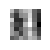

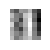

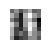

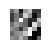

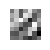

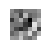

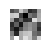

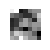

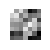

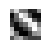

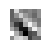

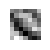

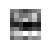

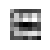

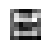

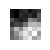

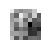

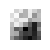

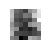

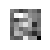

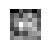

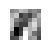

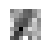

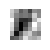

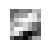

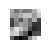

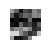

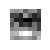

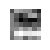

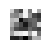

In [ ]:
# Visualize weights as images
def imshow(img):
    plt.figure(figsize=(0.4, 0.4))
    plt.imshow(img, cmap="gray")
    plt.axis('off')
    plt.show()

# Get the weights
for name, param in net.named_parameters():
    if 'weight' in name:
        weights = param.data.cpu()
        # Visualize the weights as images
        if len(weights.size()) == 4:  # Convolutional layer
            print(name)
            for i in range(weights.size(0)):
                for j in range(weights.size(1)):
                  imshow(weights[i,j])



## Part 2: Transfer Learning with Pre-trained Deep Networks

Training deep networks from scratch requires massive datasets and significant computational power. **Transfer Learning** allows us to take a model that has already been trained on a massive dataset (like **ImageNet**, which has 1.2 million images and 1,000 classes) and repurpose its learned feature extractors for our own specific task (like CIFAR-10).

### The ResNet Architecture (Residual Networks)
Before 2015, researchers noticed a strange phenomenon: as neural networks got deeper, their performance eventually plateaued and then *degraded*. This wasn't just overfitting; the training error was getting worse. This was largely due to the **Vanishing Gradient Problem**: as gradients are back-propagated to earlier layers, repeated multiplication makes them infinitely small, halting learning.

ResNets (introduced by He et al.) solved this by introducing **Skip Connections** (or Residual Connections). Instead of forcing a layer to learn an underlying mapping $H(x)$, a skip connection bypasses one or more layers, allowing the network to learn a residual function $F(x) = H(x) - x$.

This essentially creates "highways" for gradients to flow backward unimpeded, allowing researchers to successfully train networks that are hundreds of layers deep.

### Challenge 1: Feature Extraction and Fine-Tuning ResNet18

Pretrained models are trained with specific image preprocessing (normalization means and standard deviations). We must apply these exact same transformations to our CIFAR-10 dataset, which is why we utilize the `preprocess` transforms extracted from the weights above.

**The Problem:**
The pre-trained ResNet18 outputs a vector of size 1000 (for the 1000 ImageNet classes). Our CIFAR-10 dataset only has 10 classes.

**The Task:**
1. **Network Surgery**: You need to modify the architecture. In PyTorch, the final classification layer of a ResNet is named `.fc` (fully connected). We need to replace this layer with a new one that maps from the ResNet's output feature size (512 for ResNet18) to our 10 classes.
2. **Freezing Gradients**: Since the convolutional layers already know how to extract great visual features, we don't want to ruin their weights. We will "freeze" the network by setting `requires_grad = False` for all parameters *except* our newly added final layer.
3. **Fill in the blanks**: Complete sections in the code below to implement the forward pass, calculate the loss, and step the optimizer.

In [ ]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()
# Initialize the inference transforms
preprocess = weights.transforms()
print(preprocess)
# Apply inference preprocessing transforms to the dataloaders
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=preprocess)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                         shuffle=False, num_workers=2)



testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=preprocess)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
!pip install torchinfo

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary
model1 = models.resnet18(pretrained=True).to(device)
#model1.eval()
summary(model1, input_size=(3, 224, 224))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [ ]:
from torchsummary import summary
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

newmodel = models.resnet18(pretrained=True).to(device)
newmodel.eval()

# step 1: make a new network that will replace the resnet head, you can add more layers if you like and compare the results
out_dim = 512
class MyNewResnet(nn.Module):
  def __init__(self):
        super(MyNewResnet, self).__init__()
        #Create a linear layer with the input being the output dimension size and the output size being the number of classes in CIFAR-10
        self.fc3 = nn.Linear(out_dim, 10)

  def forward(self, x):
      x = self.fc3(x)
      return x


new_resnet = MyNewResnet().to(device)
#This replaces the Resnet classification head with our fully connected layer
newmodel.fc = new_resnet

#Here we freeze the previous layers in ResNet and only update the parameters in the final fully connected layer
for param in newmodel.parameters():
    param.requires_grad = False
for param in newmodel.fc.parameters():
  param.requires_grad = True


# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(newmodel.parameters(), lr=0.001, momentum=0.9)

# step 3: train this new network on CIFAR 10
# Training the network
for epoch in range(1):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in tqdm.tqdm(enumerate(trainloader, 0)):
        # get the inputs
        inputs, labels = data
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = newmodel(inputs.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0


# step 4: test the accuracy
correct = 0
total = 0
avg_time = []
for data in testloader:
    images, labels = data
    start = time.time()
    #outputs = newmodel(images.cuda())
    outputs = newmodel(images.to(device))
    _, predicted = torch.max(outputs.data, 1)
    end = time.time()
    total += labels.size(0)
    correct += (predicted.cpu() == labels).sum().item()
    time_taken = end - start
    avg_time.append(time_taken)

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total}%")
print(f"Avg time taken for prediction: {np.average(avg_time)}")




SyntaxError: invalid syntax (3795156574.py, line 13)

### The Effect of Training Epochs on Model Performance

In the previous cell, we trained our modified ResNet for only **1 epoch** (a single complete pass through the entire training dataset). While transfer learning allows us to get decent results quickly, a single pass is rarely enough for the newly added classification layer to fully adapt and find the optimal weights for the CIFAR-10 data.

**Why increase the epochs?**
By increasing the number of epochs (to 3, in the code below), we allow the optimizer more opportunities to iteratively adjust the weights, hopefully moving the loss closer to its minimum (convergence).

**What to watch out for as you train:**
* **Underfitting:** What we likely experienced after just 1 epoch. The network hasn't seen the data enough times to learn the underlying patterns effectively.
* **Overfitting:** If we were to increase the epochs *too* much (e.g., 50 or 100 without regularization), the model might start memorizing the specific noise in the training data rather than generalizable features, leading to a drop in test accuracy.

*Task: Run the code below to train the network for 3 epochs. Pay attention to the `loss` printed during training—it should steadily decrease—and observe how much the final test accuracy improves compared to the 1-epoch run.*

In [ ]:
from torchsummary import summary
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

newmodel = models.resnet18(pretrained=True).to(device)
newmodel.eval()

# step 1: make a new network that will replace the resnet head, you can add more layers if you like and compare the results
out_dim = 512
class MyNewResnet(nn.Module):
  def __init__(self):
        super(MyNewResnet, self).__init__()

        #Create a linear layer with the input being the output dimension size and the output size being the number of classes in CIFAR-10
        self.fc3 = nn.Linear(out_dim, 10)

  def forward(self, x):
      x = self.fc3(x)
      return x


new_resnet = MyNewResnet().to(device)
#This replaces the Resnet classification head with our fully connected layer
newmodel.fc = new_resnet
#print(new_resnet)
for param in newmodel.parameters():
    param.requires_grad = False
for param in newmodel.fc.parameters():
  param.requires_grad = True


# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(newmodel.parameters(), lr=0.001, momentum=0.9)

# step 3: train this new network on CIFAR 10
# Training the network
for epoch in range(3):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in tqdm.tqdm(enumerate(trainloader, 0)):
        # get the inputs
        inputs, labels = data
        # zero the parameter gradients
        optimizer.zero_grad()


        # forward + backward + optimize
        outputs = newmodel(inputs.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0


# step 4: test the accuracy
correct = 0
total = 0
avg_time = []
for data in testloader:
    images, labels = data
    start = time.time()
    outputs = newmodel(images.to(device))
    _, predicted = torch.max(outputs.data, 1)
    end = time.time()
    total += labels.size(0)
    correct += (predicted.cpu() == labels).sum().item()
    time_taken = end - start
    avg_time.append(time_taken)

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total}%")
print(f"Avg time taken for prediction: {np.average(avg_time)}")


### Challenge 2: Scaling up to ResNet50

We've seen how transfer learning performs with ResNet18 (which has 18 layers and roughly 11 million parameters). Now, try adapting the code above to use **ResNet50**.

**Key Differences:**
* The feature dimension before the final fully connected layer in ResNet50 is **2048**, not 512. You will need to adjust your `MyNewResnet` input size accordingly!

*Task: Copy your code from above, change the model import to `resnet50(pretrained=True)`, adjust the input dimensions of your final layer, and observe if the increased capacity improves your CIFAR-10 accuracy.*

### Misc Notes:

Fore more state-of-the art models, refer to Huggingface. https://huggingface.co/models

https://www.cs.cmu.edu/~epxing/Class/10708-19/notes/lecture-16/ - CNN section.
https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf - NeurIPS paper that showed feature hierarchy in CNN's.



